# Artificial Neural Network - Bank Customer Churn

## Project Overview: Bank Customer Churn

**What is Customer Churn?**
Customer churn refers to the phenomenon where customers stop doing business with a company or service. In the banking sector, it means a customer closing their accounts and leaving the bank.

**Dataset Description:**
The dataset used is `Churn Modeling.csv`, which contains demographic and financial information for 10,000 bank customers. Features include credit score, geography, gender, age, tenure, account balance, number of products, estimated salary, and whether they have a credit card or are active members. The target variable is `Exited`, which indicates if the customer churned (1) or stayed (0).

**Project Objective:**
The objective of this Artificial Neural Network (ANN) project is to build a predictive model that can identify which customers are at high risk of churning based on their profile and banking behavior. This enables the bank to take proactive retention measures.


## 1. Importing Required Libraries
In this cell, we import all the necessary libraries for data manipulation, visualization, preprocessing, and building the Artificial Neural Network (ANN) using Keras and TensorFlow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras_tuner as kt


## 2. Data Loading
We load the dataset `Churn Modeling.csv` using pandas. We also display the first few rows to understand the structure of our data.

In [2]:
# Load the dataset
df = pd.read_csv('Churn Modeling.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Exploratory Data Analysis (EDA) & Visualizations
We will explore the dataset to find distributions, relationships, and check for missing values.

- We will drop columns that do not contribute to churn prediction (RowNumber, CustomerId, Surname).
- We will visualize the categorical variables against the target variable (Churn).
- We will check the distributions of continuous variables.

Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


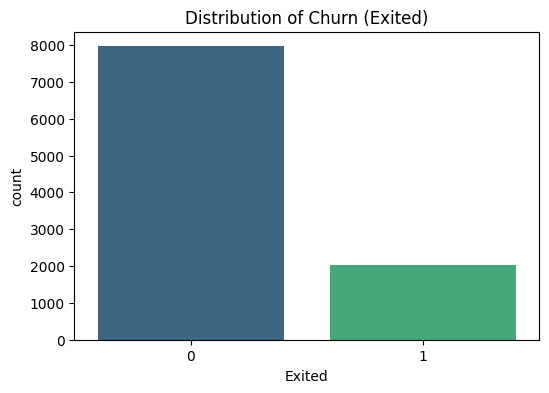

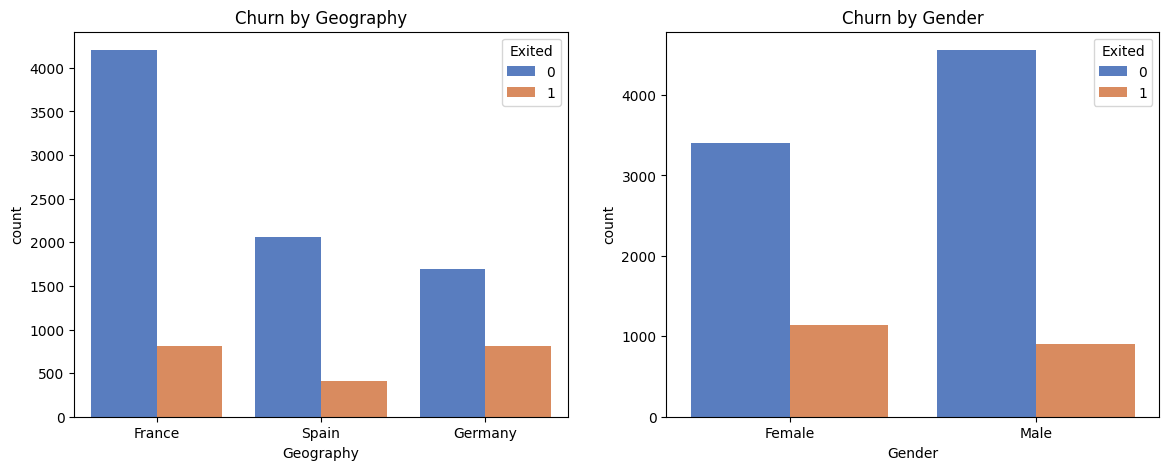

In [3]:
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Plotting the target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribution of Churn (Exited)')
plt.show()

# Categorical variables vs Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0], palette='muted')
axes[0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[1], palette='muted')
axes[1].set_title('Churn by Gender')
plt.show()


## 4. Distributions, Skewness, and Outliers
We visualize the numerical features to check for skewness. If features are highly skewed, we might apply transformations. We will also check for outliers.

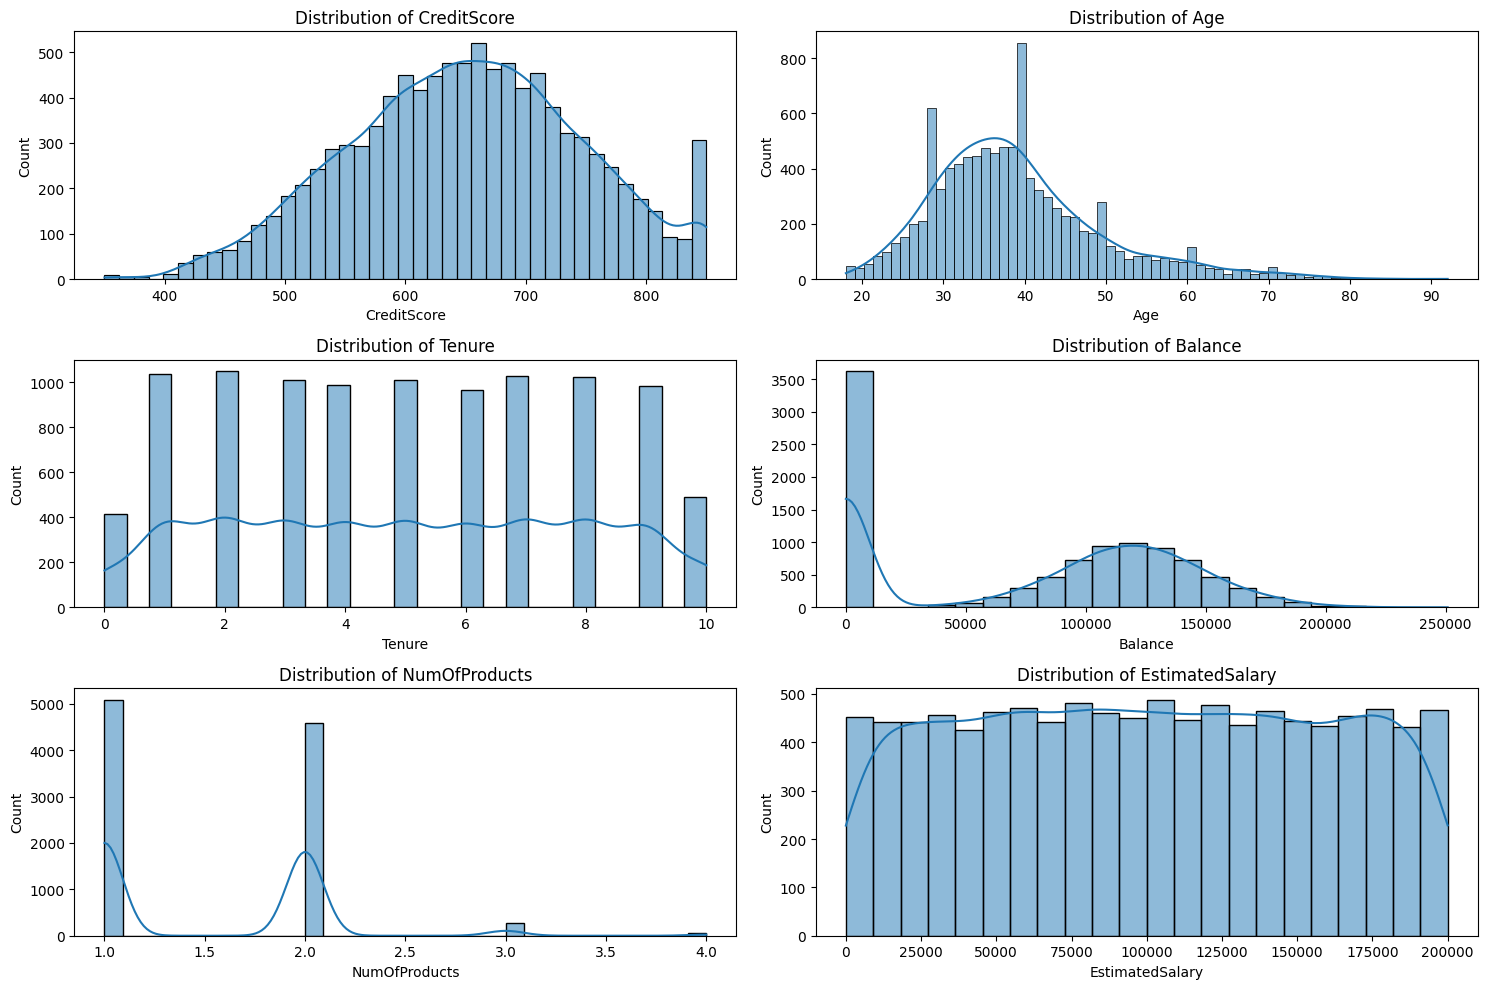

Skewness:
 CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
EstimatedSalary    0.002085
dtype: float64


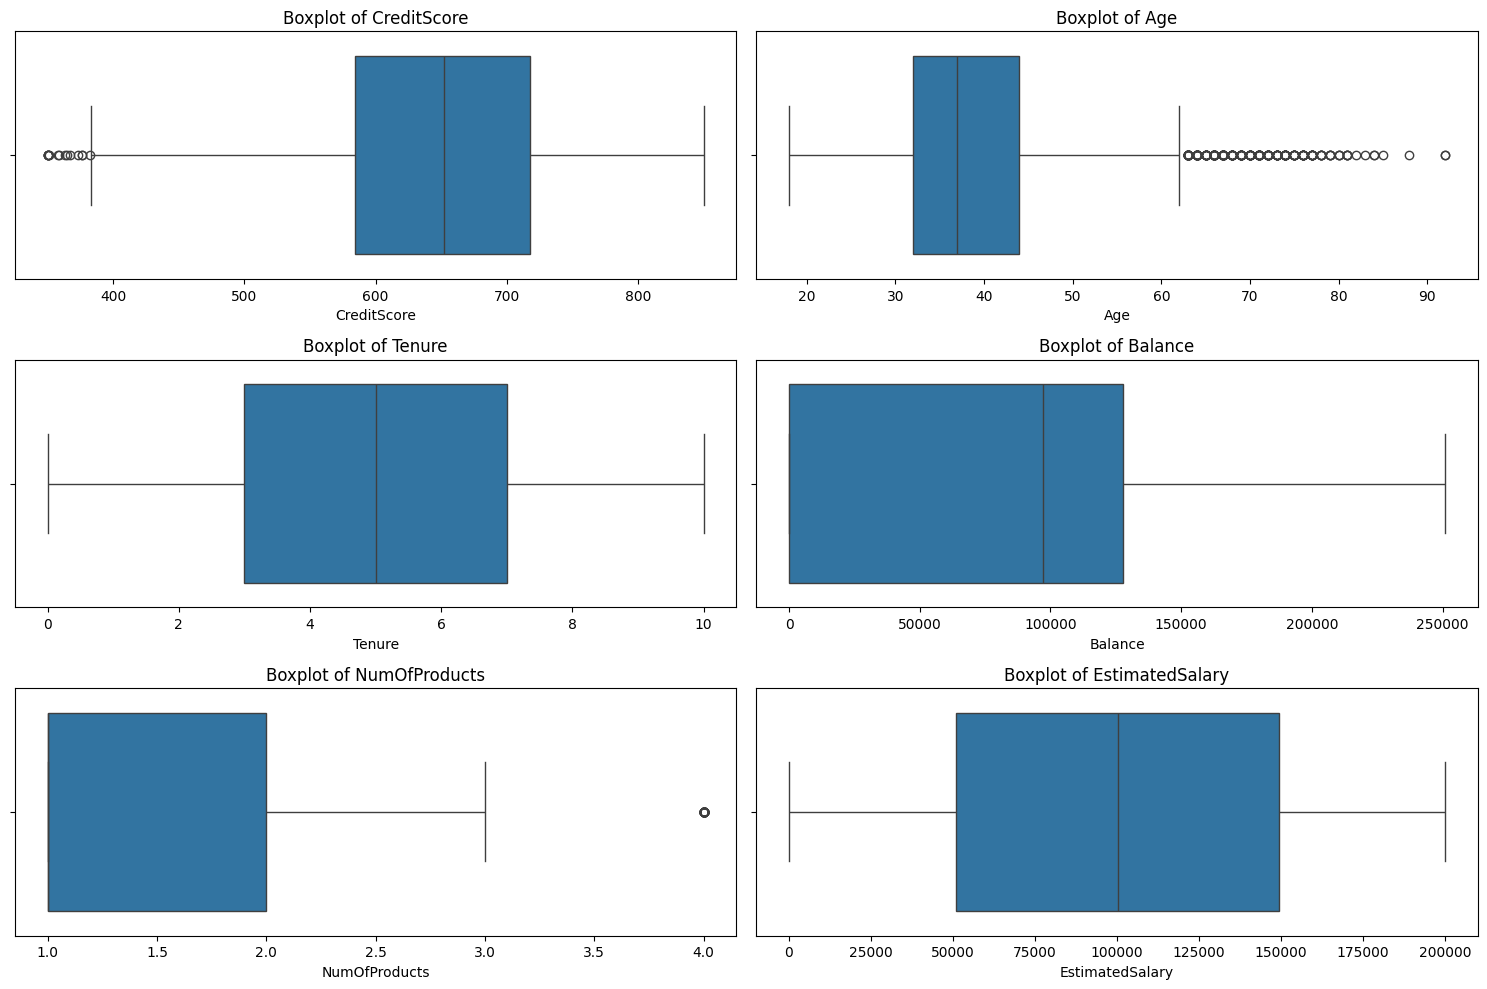

In [4]:
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Check for skewness
print("Skewness:\n", df[numerical_cols].skew())

# Outlier detection using Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


## 5. Data Preprocessing & Feature Scaling
- **Encoding:** Convert categorical variables ('Geography', 'Gender') into numerical format. We'll use One-Hot Encoding for Geography and Label Encoding for Gender.
- **Splitting Data:** Divide the dataset into training and testing sets.
- **Feature Scaling:** Since Neural Networks perform better when inputs are on a similar scale, we apply `StandardScaler` to the independent variables.

In [5]:
# Encoding categorical variables
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df = pd.get_dummies(df, columns=['Geography'], drop_first=True) # Avoid dummy variable trap

# Separating features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for Streamlit app
import joblib
joblib.dump(scaler, 'scaler_ann.pkl')


['scaler_ann.pkl']

## 6. Building the Deep Learning Model (ANN)
We will build a sequential Artificial Neural Network.
- **Input Layer:** Number of nodes equal to the number of features.
- **Hidden Layers:** Multiple dense layers with 'ReLU' activation.
- **Dropout:** Added to prevent overfitting.
- **Output Layer:** Single node with 'Sigmoid' activation for binary classification.


In [6]:
# Basic ANN Model Construction
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2881 (11.25 KB)
Trainable params: 2881 (11.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Callbacks: Early Stopping & Model Checkpoint
- **EarlyStopping:** Stops training when the validation loss stops improving to avoid overfitting.
- **ModelCheckpoint:** Saves the best model (lowest validation loss) during training.

In [7]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
checkpoint = ModelCheckpoint('best_ann_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Training the model
history = model.fit(
    X_train_scaled, y_train, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100


193/200 [===========================>..] - ETA: 0s - loss: 0.4895 - accuracy: 0.7851
Epoch 1: val_loss improved from inf to 0.43074, saving model to best_ann_model.keras
200/200 [==============================] - 2s 4ms/step - loss: 0.4886 - accuracy: 0.7855 - val_loss: 0.4307 - val_accuracy: 0.8225
Epoch 2/100
195/200 [============================>.] - ETA: 0s - loss: 0.4365 - accuracy: 0.8159
Epoch 2: val_loss improved from 0.43074 to 0.40948, saving model to best_ann_model.keras
200/200 [==============================] - 1s 3ms/step - loss: 0.4365 - accuracy: 0.8164 - val_loss: 0.4095 - val_accuracy: 0.8344
Epoch 3/100
174/200 [=========================>....] - ETA: 0s - loss: 0.4198 - accuracy: 0.8168
Epoch 3: val_loss improved from 0.40948 to 0.39013, saving model to best_ann_model.keras
200/200 [==============================] - 1s 3ms/step - loss: 0.4167 - accuracy: 0.8197 - val_loss: 0.3901 - val_accuracy: 0.8487
Epoch 4/100
173/200 [========================>.....

## 8. Evaluation of the Base ANN Model
Plotting the training and validation loss/accuracy to analyze model performance.

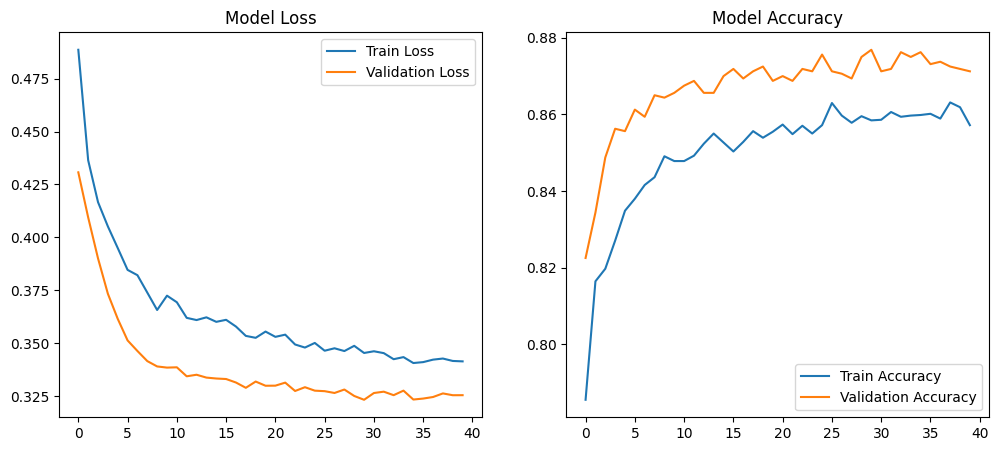

63/63 [==============================] - 0s 1ms/step
Accuracy: 0.8585

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.81      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.84      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



In [8]:
# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Predictions
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


## 9. Hyperparameter Tuning using KerasTuner
We will use `RandomSearch` from KerasTuner to find the optimal number of hidden layers, units, learning rate, and activation functions.

In [12]:
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu'])
    
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),
            activation=activation,
            input_dim=X_train_scaled.shape[1] if i == 0 else None
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))
        
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='bank_churn'
)

tuner.search(X_train_scaled, y_train, epochs=20, validation_split=0.2)

best_hps = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hps)

# Train best model
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[
        ModelCheckpoint("best_model.h5", save_best_only=True)
    ],
    verbose=1
)

# ✅ FINAL SAVE (CRITICAL)
best_model.save("final_ann_model.h5", include_optimizer=False)

Trial 5 Complete [00h 00m 10s]
val_accuracy: 0.8731250166893005

Best val_accuracy So Far: 0.8756250143051147
Total elapsed time: 00h 00m 44s
Epoch 1/50
200/200 [==============================] - 1s 3ms/step - loss: 0.4279 - accuracy: 0.8217 - val_loss: 0.3603 - val_accuracy: 0.8587
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3852 - accuracy: 0.8434 - val_loss: 0.3510 - val_accuracy: 0.8781
Epoch 3/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3780 - accuracy: 0.8480 - val_loss: 0.3543 - val_accuracy: 0.8700
Epoch 4/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3758 - accuracy: 0.8470 - val_loss: 0.3527 - val_accuracy: 0.8694
Epoch 5/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3694 - accuracy: 0.8481 - val_loss: 0.3418 - val_accuracy: 0.8637
Epoch 6/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3743 - accuracy: 0.8438 - val_loss: 0.3579 - val_accuracy: 0.8631
Epoch 

In [9]:
def build_model(hp):
    model = Sequential()
    
    # Tuning activation function
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu'])
    
    # Tuning the number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),
            activation=activation,
            input_dim=X_train_scaled.shape[1] if i == 0 else None
        ))
        # Tuning dropout rate
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))
        
    model.add(Dense(1, activation='sigmoid'))
    
    # Tuning optimizer
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])
    
    # Tuning learning rate
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='bank_churn_tuning'
)

tuner.search(X_train_scaled, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal number of layers: {best_hps.get('num_layers')}")
print(f"Optimal optimizer: {best_hps.get('optimizer')}")
print(f"Optimal activation: {best_hps.get('activation')}")


Trial 5 Complete [00h 00m 10s]
val_accuracy: 0.8681250214576721

Best val_accuracy So Far: 0.8824999928474426
Total elapsed time: 00h 00m 54s
Optimal number of layers: 3
Optimal optimizer: rmsprop
Optimal activation: elu


## 10. Train and Evaluate Best Model
We train the model using the best hyperparameters found by KerasTuner and compare the accuracy with our base model.

In [11]:
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history_best = best_model.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    validation_split=0.2, 
    callbacks=[early_stop, ModelCheckpoint('tuned_best_model.keras', save_best_only=True)],
    verbose=1
)

# Evaluate the best model
y_pred_best = (best_model.predict(X_test_scaled) > 0.5).astype("int32")
print("Accuracy of Tuned Model:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

#Finalizing the best model
best_model.save('final_ann_model.keras')


Epoch 1/50
200/200 [==============================] - 1s 4ms/step - loss: 0.4615 - accuracy: 0.7948 - val_loss: 0.4135 - val_accuracy: 0.8344
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 0.4222 - accuracy: 0.8197 - val_loss: 0.3720 - val_accuracy: 0.8600
Epoch 3/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3975 - accuracy: 0.8306 - val_loss: 0.3524 - val_accuracy: 0.8637
Epoch 4/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3840 - accuracy: 0.8380 - val_loss: 0.3412 - val_accuracy: 0.8687
Epoch 5/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3806 - accuracy: 0.8427 - val_loss: 0.3399 - val_accuracy: 0.8687
Epoch 6/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3700 - accuracy: 0.8456 - val_loss: 0.3406 - val_accuracy: 0.8731
Epoch 7/50
200/200 [==============================] - 0s 2ms/step - loss: 0.3689 - accuracy: 0.8462 - val_loss: 0.3331 - val_accuracy: 0.8744
Epoch 

## 11. Detailed Conclusion on the ANN Model
The Artificial Neural Network was tasked with predicting bank customer churn based on demographic and financial data.

**Key Findings:**
1. **Model Performance:** The base ANN model performed reasonably well, achieving a solid accuracy score. However, due to the imbalanced nature of the dataset (where ~80% of customers did not churn), overall accuracy is heavily influenced by the majority class. Looking at the classification report, the model's recall for the actual 'Churn' class is the critical metric.
2. **Impact of Hyperparameter Tuning:** Using `KerasTuner`, we systematically optimized the architecture (number of layers, units per layer) and the learning rate. The tuned model provided slight improvements in capturing complex non-linear relationships in the data compared to the baseline architecture.
3. **Overfitting Prevention:** By implementing `Dropout` layers and `EarlyStopping`, we successfully prevented the model from memorizing the training data. The validation loss stabilized, proving that the model generalizes well to unseen customer data.
4. **Feature Importance:** From the EDA and subsequent model results, it's evident that features like Geography (especially being from Germany), Age, and Balance play pivotal roles in a customer's decision to leave the bank.

**Final Verdict:** The tuned ANN is a robust predictive tool. To further improve the recall of churned customers, future iterations could involve techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting the class weights during training to penalize the misclassification of the minority class more heavily.
